In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from scipy import stats
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone

def histogram_features(image):
    if len(image.shape) == 2:
        image_gray = image
    else:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([image_gray], [0], None, [256], [0, 256])
    hist = hist.flatten()
    hist = hist / hist.sum()   
    values = np.arange(256)
    features = {}
    features['mean'] = np.sum(hist * values)
    variance = np.sum(hist * (values - features['mean'])**2)
    features['std'] = np.sqrt(variance)
    if features['std'] > 0:
        features['skewness'] = np.sum(hist * ((values - features['mean']) / features['std'])**3)
    else:
        features['skewness'] = 0
    if features['std'] > 0:
        features['kurtosis'] = np.sum(hist * ((values - features['mean']) / features['std'])**4) - 3
    else:
        features['kurtosis'] = -3
    non_zero_probs = hist[hist > 0]
    features['entropy'] = -np.sum(non_zero_probs * np.log2(non_zero_probs))
    cumulative_hist = np.cumsum(hist)
    features['q1'] = np.argmax(cumulative_hist >= 0.25) 
    features['q2'] = np.argmax(cumulative_hist >= 0.5)  
    features['q3'] = np.argmax(cumulative_hist >= 0.75) 
    non_zero_bins = np.where(hist > 0)[0]
    if len(non_zero_bins) > 0:
        features['min'] = non_zero_bins[0]
        features['max'] = non_zero_bins[-1]
    else:
        features['min'] = 0
        features['max'] = 255
    return features, hist, image_gray

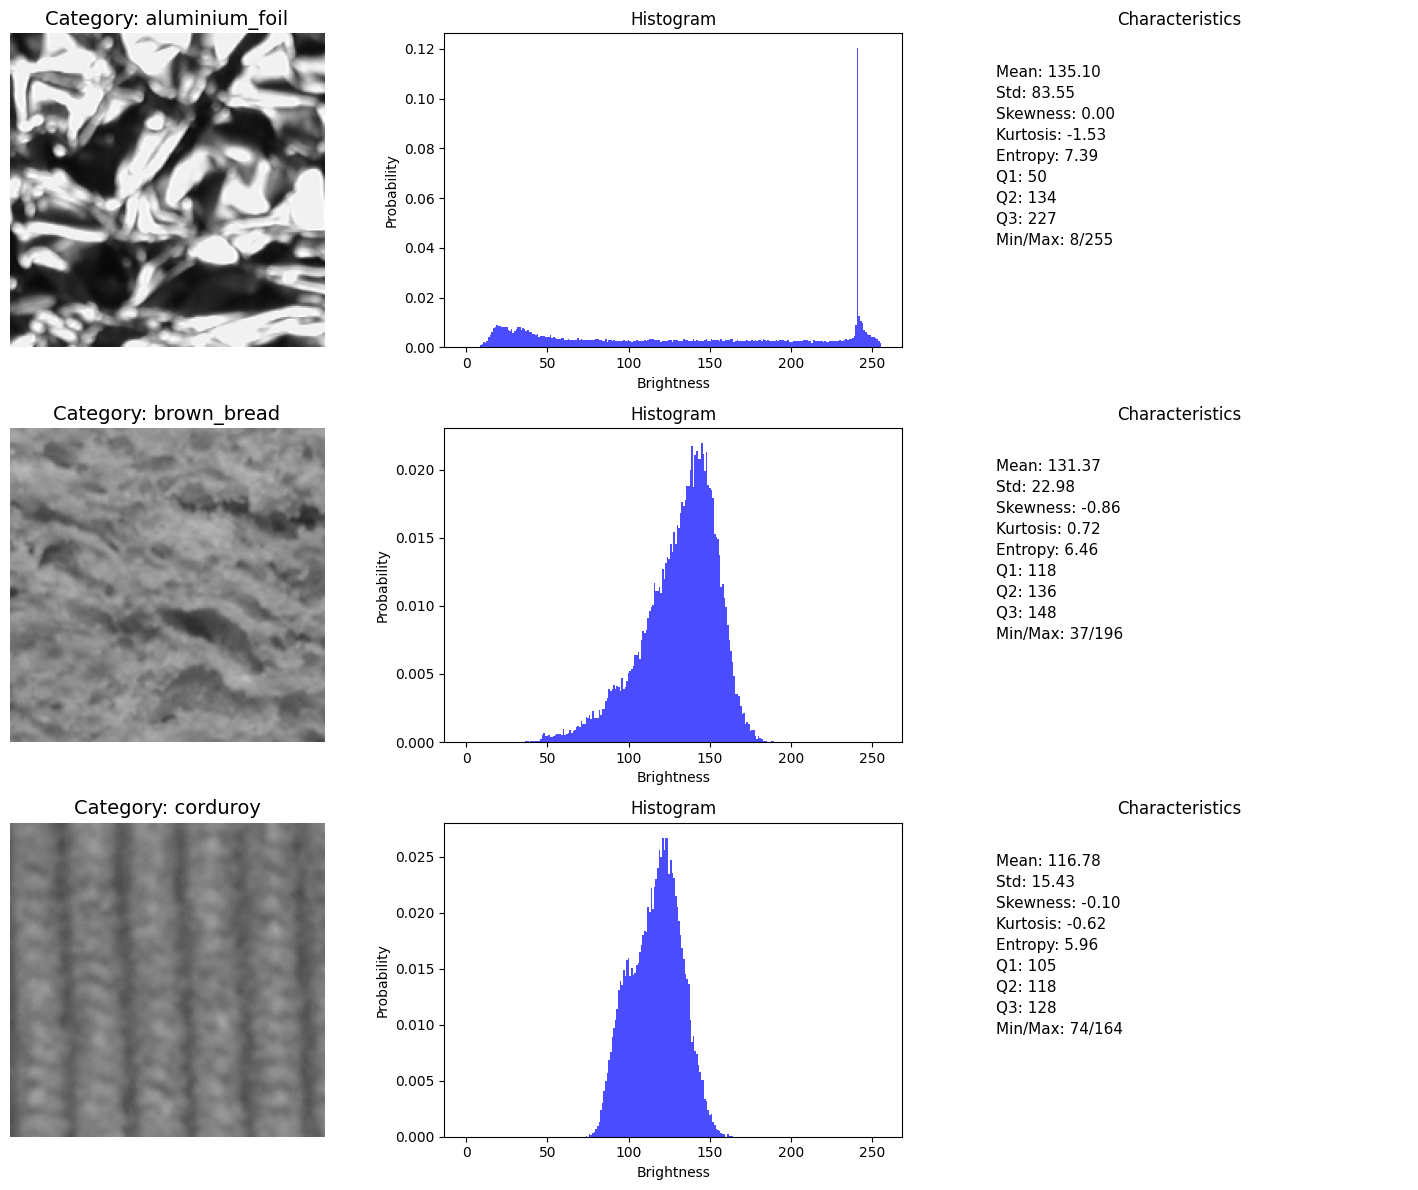

In [42]:
def analyze_histogram_categories(image_folder, num_examples=2):
    texture_categories = [f for f in os.listdir(image_folder) 
                         if os.path.isdir(os.path.join(image_folder, f))]    
    texture_categories = texture_categories[:num_examples] 
    fig, axes = plt.subplots(num_examples, 3, figsize=(15, 4*num_examples))   
    for i, category in enumerate(texture_categories):
        category_path = os.path.join(image_folder, category)
        image_files = [f for f in os.listdir(category_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]            
        first_image_path = os.path.join(category_path, image_files[0])
        image = cv2.imread(first_image_path)
        features, hist, image_gray = histogram_features(image)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Category: {category}', fontsize=14)
        axes[i, 0].axis('off')
        
        axes[i, 1].bar(range(256), hist, alpha=0.7, color='blue', width=1.0)
        axes[i, 1].set_title('Histogram', fontsize=12)
        axes[i, 1].set_xlabel('Brightness')
        axes[i, 1].set_ylabel('Probability')
        
        metrics_text = (
            f"Mean: {features['mean']:.2f}\n"
            f"Std: {features['std']:.2f}\n"
            f"Skewness: {features['skewness']:.2f}\n"
            f"Kurtosis: {features['kurtosis']:.2f}\n"
            f"Entropy: {features['entropy']:.2f}\n"
            f"Q1: {features['q1']}\n"
            f"Q2: {features['q2']}\n"
            f"Q3: {features['q3']}\n"
            f"Min/Max: {features['min']}/{features['max']}"
        )
        
        axes[i, 2].text(0.1, 0.9, metrics_text, transform=axes[i, 2].transAxes, 
                       fontsize=11, verticalalignment='top', linespacing=1.5)
        axes[i, 2].set_title('Characteristics', fontsize=12)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
analyze_histogram_categories(r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS", num_examples=3)  

In [49]:
def Laws_features(image):
    L5 = np.array([1, 4, 6, 4, 1])    
    E5 = np.array([-1, -2, 0, 2, 1])  
    S5 = np.array([-1, 0, 2, 0, -1])  
    W5 = np.array([-1, 2, 0, -2, 1])
    R5 = np.array([1, -4, 6, -4, 1])     
    kernels = [L5, E5, S5, W5, R5]
    kernel_names = ['L5', 'E5', 'S5', 'W5', 'R5']
    if len(image.shape) == 2:
        image_gray = image
    else:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laws_features = {}
    for i in range(len(kernels)):
        for j in range(len(kernels)):
            kernel_2d = np.outer(kernels[i], kernels[j])
            filtered = cv2.filter2D(image_gray.astype(np.float32), -1, kernel_2d)
            energy = np.mean(np.abs(filtered))
            
            feature_name = f"{kernel_names[i]}{kernel_names[j]}"
            laws_features[feature_name] = energy 
    return laws_features, image_gray

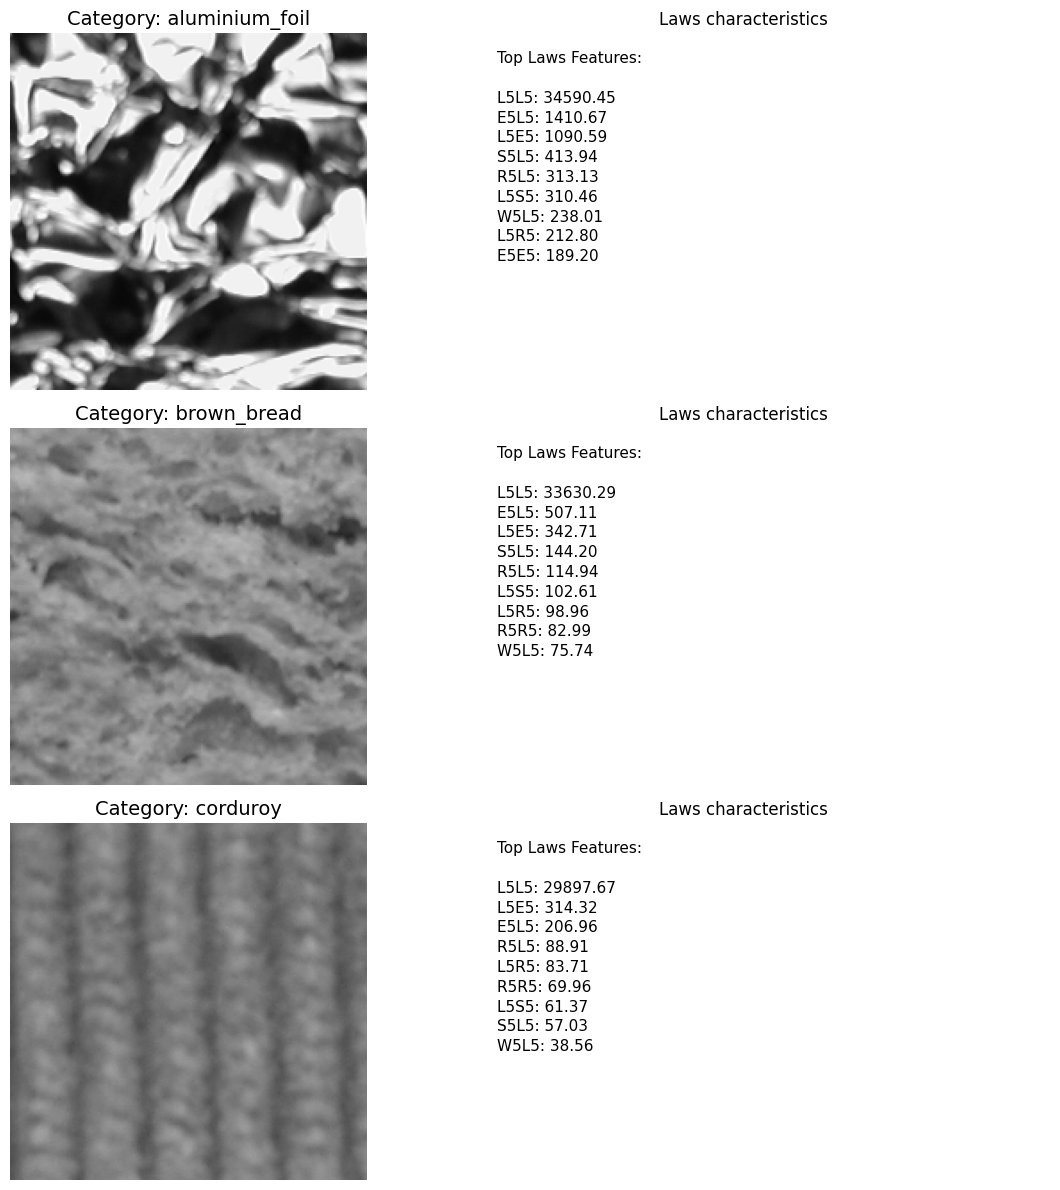

In [50]:
def analyze_laws_categories(image_folder, num_examples=2):
    texture_categories = [f for f in os.listdir(image_folder) 
                         if os.path.isdir(os.path.join(image_folder, f))]    
    texture_categories = texture_categories[:num_examples]   
    fig, axes = plt.subplots(num_examples, 2, figsize=(12, 4*num_examples))    
    for i, category in enumerate(texture_categories):
        category_path = os.path.join(image_folder, category)      
        image_files = [f for f in os.listdir(category_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]         
        first_image_path = os.path.join(category_path, image_files[0])
        image = cv2.imread(first_image_path)    
        laws_features, img_gray = Laws_features(image)
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Category: {category}', fontsize=14)
        axes[i, 0].axis('off')  
        sorted_laws = sorted(laws_features.items(), key=lambda x: x[1], reverse=True)[:9]   
        laws_text = "Top Laws Features:\n\n"
        for name, value in sorted_laws:
            laws_text += f"{name}: {value:.2f}\n"        
        axes[i, 1].text(0.1, 0.95, laws_text, transform=axes[i, 1].transAxes, 
                       fontsize=11, verticalalignment='top', linespacing=1.4)
        axes[i, 1].set_title('Laws characteristics', fontsize=12)
        axes[i, 1].axis('off')    
    plt.tight_layout()
    plt.show()
analyze_laws_categories(r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS", num_examples=3)

In [51]:
def GLCM_features(image):
    if len(image.shape) == 2:
        image_gray = image
    else:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img_quantized = (image_gray / 32).astype(np.uint8)    
    glcm = graycomatrix(img_quantized, 
                       distances=[1, 2], 
                       angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                       levels=8, 
                       symmetric=True, 
                       normed=True)   
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']    
    glcm_features = {}    
    for prop in properties:
        feature_val = graycoprops(glcm, prop)
        for dist_idx, distance in enumerate([1, 2]):
            for angle_idx, angle in enumerate([0, 45, 90, 135]):
                feature_name = f"{prop}_d{distance}_a{angle}"
                glcm_features[feature_name] = feature_val[dist_idx, angle_idx]   
    return glcm_features, image_gray

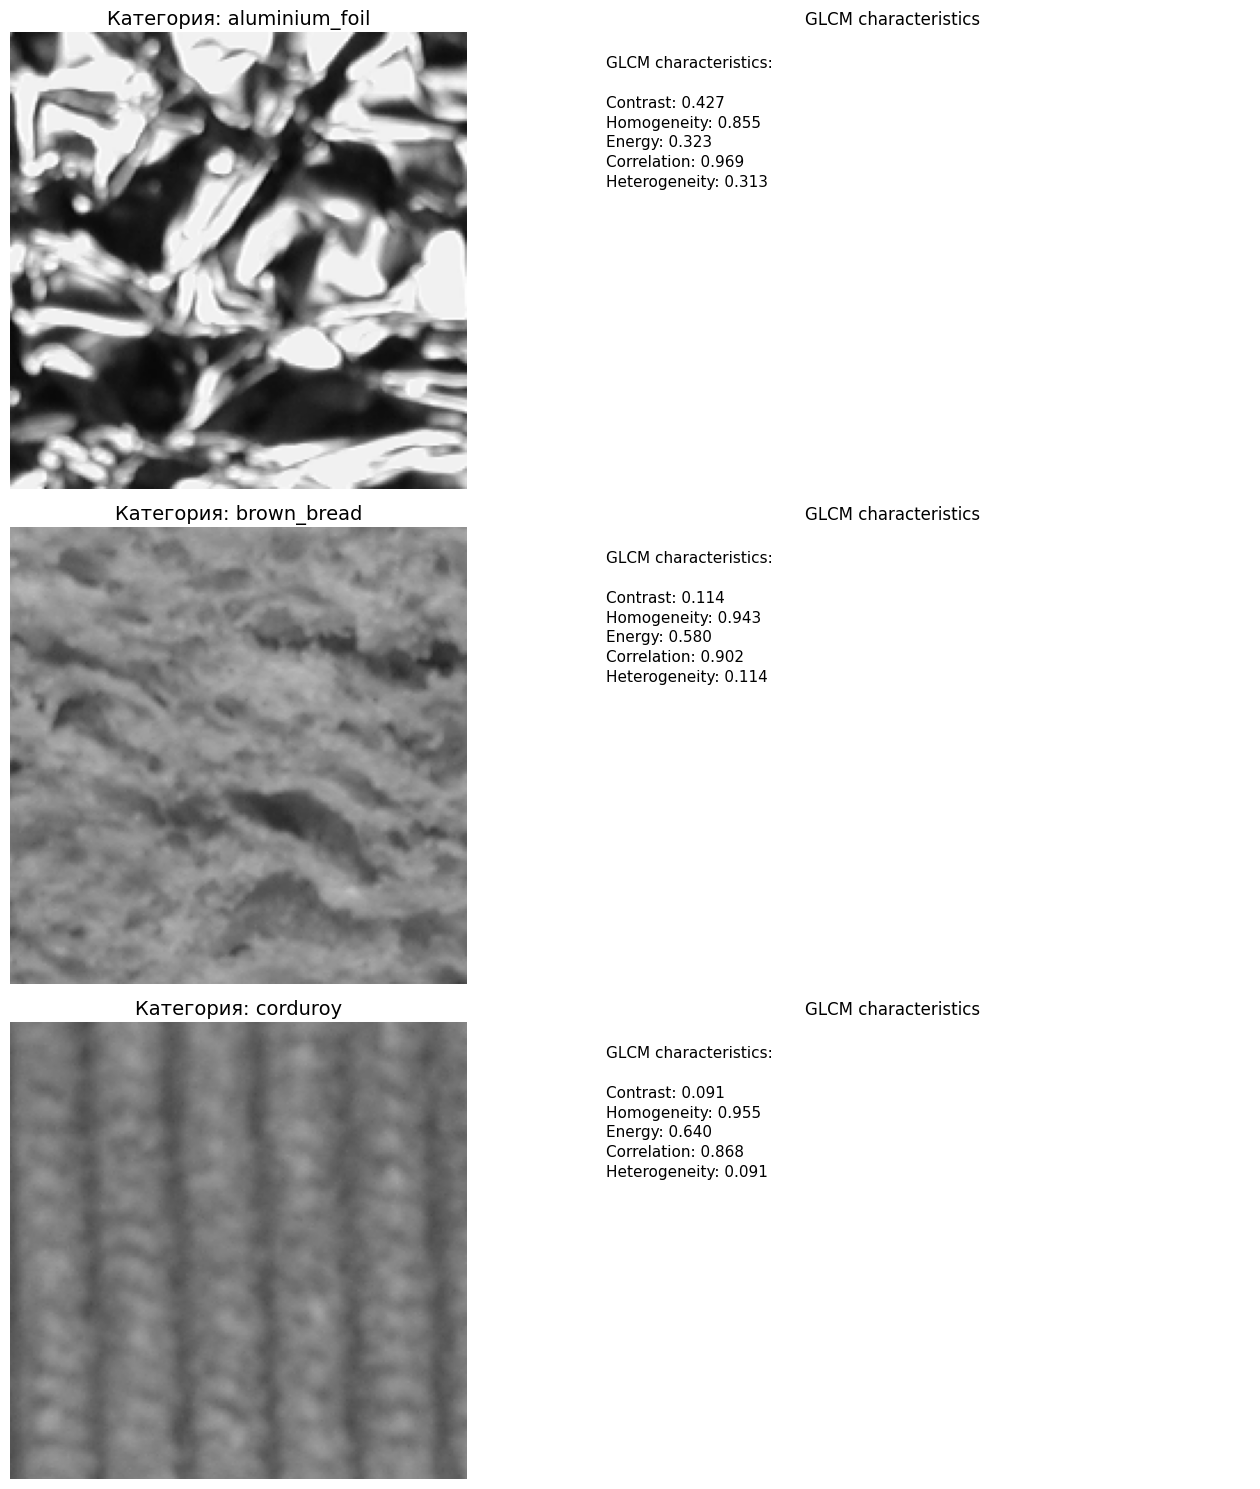

In [52]:
def analyze_glcm_categories(image_folder, num_examples=2):
    texture_categories = [f for f in os.listdir(image_folder) 
                         if os.path.isdir(os.path.join(image_folder, f))]    
    texture_categories = texture_categories[:num_examples]    
    fig, axes = plt.subplots(num_examples, 2, figsize=(14, 5*num_examples))  
    def get_best_value(features_dict, feature_type):
        if not features_dict:
            return 0.0     
        if feature_type in ['contrast', 'dissimilarity']:
            return min(features_dict.values())
        else:
            return max(features_dict.values()) 
    for i, category in enumerate(texture_categories):
        category_path = os.path.join(image_folder, category)   
        image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        first_image_path = os.path.join(category_path, image_files[0])
        image = cv2.imread(first_image_path)
        glcm_features, img_gray = GLCM_features(image)   
        axes[i, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f'Категория: {category}', fontsize=14)
        axes[i, 0].axis('off')
        glcm_text = "GLCM characteristics:\n\n"        
        contrast_features = {k: v for k, v in glcm_features.items() if 'contrast' in k}
        glcm_text += f"Contrast: {get_best_value(contrast_features, 'contrast'):.3f}\n"
        homogeneity_features = {k: v for k, v in glcm_features.items() if 'homogeneity' in k}
        glcm_text += f"Homogeneity: {get_best_value(homogeneity_features, 'homogeneity'):.3f}\n"
        energy_features = {k: v for k, v in glcm_features.items() if 'energy' in k}
        glcm_text += f"Energy: {get_best_value(energy_features, 'energy'):.3f}\n"
        correlation_features = {k: v for k, v in glcm_features.items() if 'correlation' in k}
        glcm_text += f"Correlation: {get_best_value(correlation_features, 'correlation'):.3f}\n"
        dissimilarity_features = {k: v for k, v in glcm_features.items() if 'dissimilarity' in k}
        glcm_text += f"Heterogeneity: {get_best_value(dissimilarity_features, 'dissimilarity'):.3f}\n"
        axes[i, 1].text(0.1, 0.95, glcm_text, transform=axes[i, 1].transAxes, 
                       fontsize=11, verticalalignment='top', linespacing=1.4)
        axes[i, 1].set_title('GLCM characteristics', fontsize=12)
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()
analyze_glcm_categories(r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS", num_examples=3)

In [53]:
image_folder = r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS"
image_paths = []
for class_folder in os.listdir(image_folder):
    class_path = os.path.join(image_folder, class_folder)
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_path, file))
X_hist = []  
X_laws = []  
X_glcm = []  
y = []      
for i, path in enumerate(image_paths):
    if i % 50 == 0:
        print(f"Обработано {i}/{len(image_paths)} изображений") 
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)   
    hist_features, _, _ = histogram_features(image)  
    laws_features, _ = Laws_features(image)    
    glcm_features, _ = GLCM_features(image)         
    X_hist.append(hist_features)
    X_laws.append(laws_features)
    X_glcm.append(glcm_features)
    label = os.path.basename(os.path.dirname(path))
    y.append(label)
def features_to_array(features_list):
    feature_arrays = []
    for features in features_list:
        feature_arrays.append(list(features.values()))
    return np.array(feature_arrays)
X_hist_array = features_to_array(X_hist)
X_laws_array = features_to_array(X_laws) 
X_glcm_array = features_to_array(X_glcm)
y = np.array(y)
print(f"Размеры данных:")
print(f"Histogram: {X_hist_array.shape}")
print(f"Laws: {X_laws_array.shape}")
print(f"GLCM: {X_glcm_array.shape}")
print(f"Количество классов: {len(np.unique(y))}")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
methods = {
    'Histogram': X_hist_array,
    'Laws': X_laws_array, 
    'GLCM': X_glcm_array
}
models = {
    'kNN': KNeighborsClassifier(n_neighbors=3),
    'SVM': SVC(kernel='rbf', random_state=42),  
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
}

Обработано 0/810 изображений
Обработано 50/810 изображений
Обработано 100/810 изображений
Обработано 150/810 изображений
Обработано 200/810 изображений
Обработано 250/810 изображений
Обработано 300/810 изображений
Обработано 350/810 изображений
Обработано 400/810 изображений
Обработано 450/810 изображений
Обработано 500/810 изображений
Обработано 550/810 изображений
Обработано 600/810 изображений
Обработано 650/810 изображений
Обработано 700/810 изображений
Обработано 750/810 изображений
Обработано 800/810 изображений
Размеры данных:
Histogram: (810, 10)
Laws: (810, 25)
GLCM: (810, 40)
Количество классов: 10


In [54]:
trained_models = {}
for method_name, X in methods.items():
    print(f"\n{method_name.upper()}")   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)   
    method_models = {}   
    for model_name, model_template in models.items():
        if model_name == 'kNN':
            model = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
        elif model_name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)
        elif model_name == 'DecisionTree':
            model = DecisionTreeClassifier(random_state=42, max_depth=10)        
        if model_name == 'SVM':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            method_models[model_name] = (model, scaler)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            method_models[model_name] = model
        
        print(f"{model_name}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        print()    
    trained_models[method_name] = method_models
selected_models = {
    'Histogram_kNN': trained_models['Histogram']['kNN'],  
    'Laws_Tree': trained_models['Laws']['DecisionTree'],                      
    'Laws_SVM': trained_models['Laws']['SVM']                                     
}


HISTOGRAM
kNN
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_bread       0.90      0.95      0.93        20
      corduroy       0.58      0.70      0.64        20
        cotton       0.55      0.52      0.54        21
       cracker       0.83      0.71      0.77        21
         linen       0.76      0.65      0.70        20
   orange_peel       0.94      0.76      0.84        21
     sandpaper       0.39      0.35      0.37        20
        sponge       0.64      0.80      0.71        20
     styrofoam       0.91      1.00      0.95        20

      accuracy                           0.74       203
     macro avg       0.75      0.74      0.74       203
  weighted avg       0.75      0.74      0.74       203


SVM
                precision    recall  f1-score   support

aluminium_foil       0.95      1.00      0.98        20
   brown_bread       0.94      0.80      0.86        20
      corduroy       0.6

In [55]:
def segment_sandwich(model_info, model_name, image_path, patch_size=32, step=16, n_classes=4):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = image.shape
    seg_map = np.zeros((h, w), dtype=np.uint8)
    all_predictions = []
    positions = []    
    for y in range(0, h - patch_size + 1, step):
        for x in range(0, w - patch_size + 1, step):
            patch = image[y:y+patch_size, x:x+patch_size]            
            if 'Histogram' in model_name:
                features_dict, _, _ = histogram_features(patch)
                features = np.array(list(features_dict.values()))
            elif 'Laws' in model_name:
                features_dict, _ = Laws_features(patch)
                features = np.array(list(features_dict.values()))
            elif 'GLCM' in model_name:
                features_dict, _ = GLCM_features(patch)
                features = np.array(list(features_dict.values()))           
            if isinstance(model_info, tuple):  
                model, scaler = model_info
                features_scaled = scaler.transform(features.reshape(1, -1))
                pred_class = model.predict(features_scaled)[0]
            else:  
                model = model_info
                pred_class = model.predict(features.reshape(1, -1))[0]               
            seg_map[y:y+patch_size, x:x+patch_size] = pred_class
            all_predictions.append(pred_class)
            positions.append((y, x))       
    unique, counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique[np.argsort(counts)[-n_classes:]]   
    seg_map_filtered = np.zeros_like(seg_map)    
    for i, class_id in enumerate(top_classes):
        seg_map_filtered[seg_map == class_id] = i   
    mask_not_in_top = ~np.isin(seg_map, top_classes)
    if np.any(mask_not_in_top):
        seg_map_filtered[mask_not_in_top] = 1   
    return seg_map_filtered

Обрабатываем: Histogram_kNN
Успешно
Обрабатываем: Laws_Tree
Успешно
Обрабатываем: Laws_SVM
Успешно


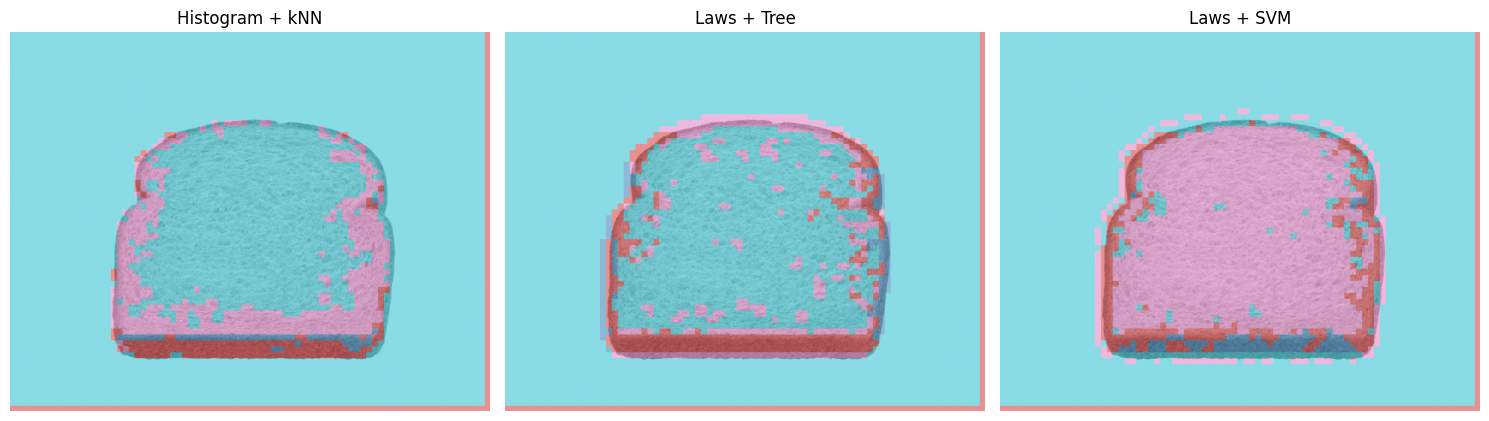

In [56]:
image_path = r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS/bed_gray.jpg"
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_img is not None:
    seg_maps = []
    model_names = []  
    for model_name, model_info in selected_models.items():
        print(f"Обрабатываем: {model_name}")      
        seg_result = segment_sandwich(model_info, model_name, image_path, patch_size=16, step=8)      
        if seg_result is not None:
            seg_maps.append(seg_result)
            model_names.append(model_name)
            print(f"Успешно")
        else:
            print(f"Ошибка")   
    if seg_maps:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))    
        for i, (seg_map, model_name) in enumerate(zip(seg_maps, model_names)):
            if 'Histogram' in model_name:
                method = 'Histogram'
                model_type = 'kNN'
            elif 'Laws' in model_name:
                method = 'Laws'
                if 'Tree' in model_name:
                    model_type = 'Tree'
                else:
                    model_type = 'SVM'          
            axes[i].imshow(original_img, cmap='gray', alpha=0.7)
            axes[i].imshow(seg_map, cmap='tab10', alpha=0.5)
            axes[i].set_title(f'{method} + {model_type}', fontsize=12)
            axes[i].axis('off')      
        plt.tight_layout()
        plt.show()

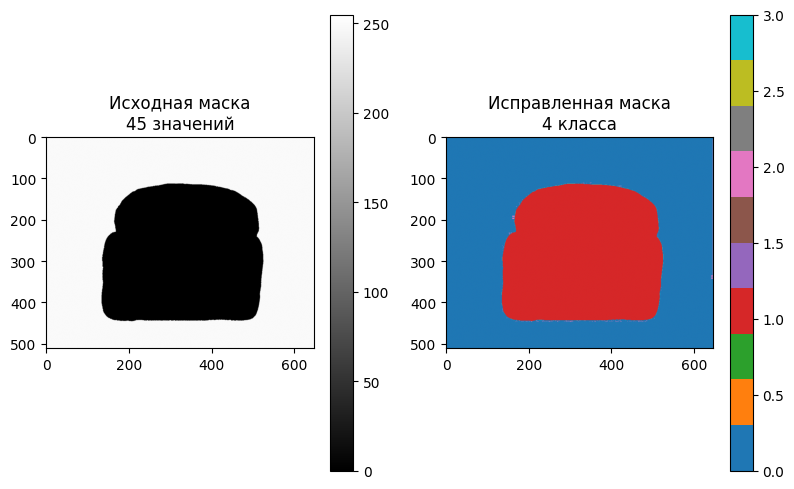

In [57]:
def keep_top_colors(mask, n_colors=4):  
    unique, counts = np.unique(mask, return_counts=True)
    sorted_indices = np.argsort(-counts)
    top_colors = unique[sorted_indices[:n_colors]]    
    result = np.zeros_like(mask)    
    for new_value, old_value in enumerate(top_colors):
        result[mask == old_value] = new_value    
    return result
manual_mask_path = r"C:/Users/User/Documents/kth_tips_grey_200x200/KTH_TIPS/bed_mask.png"
manual_mask = cv2.imread(manual_mask_path, cv2.IMREAD_GRAYSCALE)
fixed_manual_mask = keep_top_colors(manual_mask, n_colors=4)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(manual_mask, cmap='gray')
plt.title(f'Исходная маска\n{len(np.unique(manual_mask))} значений')
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(fixed_manual_mask, cmap='tab10')
plt.title('Исправленная маска\n4 класса')
plt.colorbar()
plt.tight_layout()
plt.show()


Сравнение для Laws_SVM:
Размер ручной маски: (511, 647)
Размер предсказанной маски: (511, 647)
Размер после ресайза: (511, 647)
  Предсказанный класс 0 - Ручной класс 1
  Предсказанный класс 1 - Ручной класс 1
  Предсказанный класс 2 - Ручной класс 1
  Предсказанный класс 3 - Ручной класс 0


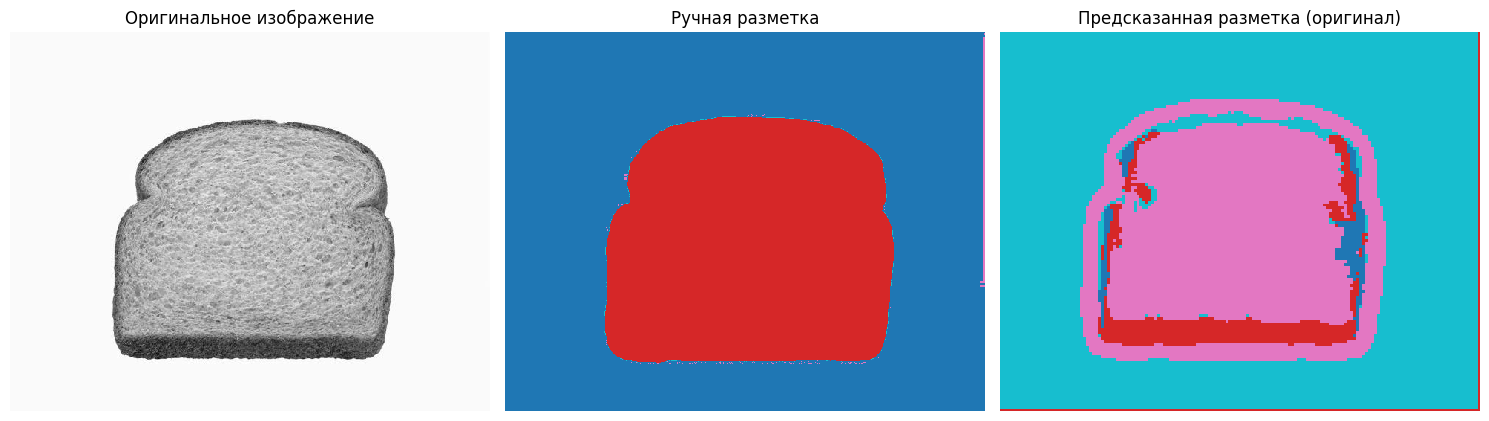

Итог: 92.8% правильных пикселей


In [58]:
from sklearn.metrics import accuracy_score, jaccard_score
def compare_simple(manual_mask, predicted_mask, model_name, original_img):
    print(f"\nСравнение для {model_name}:")
    print(f"Размер ручной маски: {manual_mask.shape}")
    print(f"Размер предсказанной маски: {predicted_mask.shape}")   
    min_height = min(manual_mask.shape[0], predicted_mask.shape[0])
    min_width = min(manual_mask.shape[1], predicted_mask.shape[1])   
    manual_resized = manual_mask[:min_height, :min_width]
    predicted_resized = predicted_mask[:min_height, :min_width]    
    print(f"Размер после ресайза: {manual_resized.shape}")    
    class_mapping = {}
    for pred_class in np.unique(predicted_resized):
        manual_classes, counts = np.unique(manual_resized[predicted_resized == pred_class], return_counts=True)
        if len(manual_classes) > 0:
            most_common_manual = manual_classes[np.argmax(counts)]
            class_mapping[pred_class] = most_common_manual
            print(f"  Предсказанный класс {pred_class} - Ручной класс {most_common_manual}")  
    pred_mapped = np.zeros_like(predicted_resized)
    for pred_class, manual_class in class_mapping.items():
        pred_mapped[predicted_resized == pred_class] = manual_class   
    accuracy = accuracy_score(manual_resized.flatten(), pred_mapped.flatten())       
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))    
    axes[0].imshow(original_img, cmap='gray', interpolation='nearest')
    axes[0].set_title('Оригинальное изображение')
    axes[0].axis('off')   
    axes[1].imshow(manual_resized, cmap='tab10', interpolation='nearest')
    axes[1].set_title('Ручная разметка')
    axes[1].axis('off')
    axes[2].imshow(predicted_resized, cmap='tab10', interpolation='nearest')
    axes[2].set_title('Предсказанная разметка (оригинал)')
    axes[2].axis('off')   
    plt.tight_layout()
    plt.show()    
    return accuracy
predicted_mask = segment_sandwich(
    selected_models["Laws_SVM"],  
    "Laws_SVM",                   
    image_path,
    patch_size=32,
    step=4,
    n_classes=4
)
if fixed_manual_mask is not None and predicted_mask is not None and original_img is not None:
    accuracy = compare_simple(fixed_manual_mask, predicted_mask, 'Laws_SVM', original_img)
    print(f"Итог: {accuracy*100:.1f}% правильных пикселей")